In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import joblib


In [3]:
file_path = r"C:\Users\Julius\Desktop\DATA APPEND_COMBATTECH\FINAL_DATA_MERGE\game_data_cleaned.csv"
df = pd.read_csv(file_path)

df.columns = (
    df.columns
      .str.strip()
      .str.upper()
      .str.replace(" ", "_")
)

df["MATCH_KEY"] = df["EVENT_NAME"].astype(str) + "-" + df["MATCH_ID"].astype(str)

df = df.sort_values(["EVENT_NAME", "MATCH_ID", "CORNER", "ROUND"])


In [4]:
df.head(10)

,YEAR,MONTH,DAY,EVENT_NAME,WEIGHT_(KG),MATCH_ID,SCHOOL_LEVEL,SEX_CATEGOY,CLASS_CATEGORY,CORNER,...,TOTAL_RAW_VIOLATION_COUNT,ROUND_SCORE,TOTAL_OVERALL_SCORE,TOTAL_OVERALL_VIOLATION,IS_PLAYER_DISQUALIFIED,PLAYER_DISQUALIFIED?,WIN_STATUS,WIN_STATUS__RESULTS,WON_BY,MATCH_KEY
270,2025,September,10,2025 BATANGAS ATHLETE DISTRICT MEET,BELOW 30 KG,1,ELEMENTARY,MALE,B,BLUE,...,0,8,0,0,NO,0,NAN,NAN,NAN,2025 BATANGAS ATHLETE DISTRICT MEET-1
271,2025,September,10,2025 BATANGAS ATHLETE DISTRICT MEET,BELOW 30 KG,1,ELEMENTARY,MALE,B,BLUE,...,1,15,0,1,NO,0,NAN,NAN,NAN,2025 BATANGAS ATHLETE DISTRICT MEET-1
272,2025,September,10,2025 BATANGAS ATHLETE DISTRICT MEET,BELOW 30 KG,1,ELEMENTARY,MALE,B,BLUE,...,0,0,23,0,NO,0,WIN,1,WINNER BY POINTS,2025 BATANGAS ATHLETE DISTRICT MEET-1
273,2025,September,10,2025 BATANGAS ATHLETE DISTRICT MEET,BELOW 30 KG,1,ELEMENTARY,MALE,B,RED,...,0,6,0,0,NO,0,NAN,NAN,NAN,2025 BATANGAS ATHLETE DISTRICT MEET-1
274,2025,September,10,2025 BATANGAS ATHLETE DISTRICT MEET,BELOW 30 KG,1,ELEMENTARY,MALE,B,RED,...,0,10,0,0,NO,0,NAN,NAN,NAN,2025 BATANGAS ATHLETE DISTRICT MEET-1
275,2025,September,10,2025 BATANGAS ATHLETE DISTRICT MEET,BELOW 30 KG,1,ELEMENTARY,MALE,B,RED,...,0,0,16,0,NO,0,LOSE,0,NAN,2025 BATANGAS ATHLETE DISTRICT MEET-1
276,2025,September,10,2025 BATANGAS ATHLETE DISTRICT MEET,BELOW 30 KG,2,ELEMENTARY,MALE,A,BLUE,...,0,6,0,0,NO,0,NAN,NAN,NAN,2025 BATANGAS ATHLETE DISTRICT MEET-2
277,2025,September,10,2025 BATANGAS ATHLETE DISTRICT MEET,BELOW 30 KG,2,ELEMENTARY,MALE,A,BLUE,...,0,5,0,0,NO,0,NAN,NAN,NAN,2025 BATANGAS ATHLETE DISTRICT MEET-2
278,2025,September,10,2025 BATANGAS ATHLETE DISTRICT MEET,BELOW 30 KG,2,ELEMENTARY,MALE,A,BLUE,...,0,0,11,0,NO,0,LOSE,0,NAN,2025 BATANGAS ATHLETE DISTRICT MEET-2
279,2025,September,10,2025 BATANGAS ATHLETE DISTRICT MEET,BELOW 30 KG,2,ELEMENTARY,MALE,A,RED,...,0,11,0,0,NO,0,NAN,NAN,NAN,2025 BATANGAS ATHLETE DISTRICT MEET-2


In [31]:
df["ROUND_OFFENSE"] = (
    df["NUM_HAND_STRIKE"] +
    df["NUM_FOOT_STRIKE"] +
    df["NUM_DROPING_SCORE"]
)

df["CUM_OFFENSE"] = df.groupby(["MATCH_KEY", "CORNER"])["ROUND_OFFENSE"].cumsum()
df["CUM_VIOLATION"] = df.groupby(["MATCH_KEY", "CORNER"])["TOTAL_RAW_VIOLATION_COUNT"].cumsum()


In [32]:
opp = df[[
    "MATCH_KEY", "ROUND", "CORNER",
    "CUM_OFFENSE", "CUM_VIOLATION"
]].copy()

opp = opp.rename(columns={
    "CORNER": "CORNER_OPP",
    "CUM_OFFENSE": "CUM_OFFENSE_OPP",
    "CUM_VIOLATION": "CUM_VIOLATION_OPP"
})

df = df.merge(opp, on=["MATCH_KEY", "ROUND"])
df = df[df["CORNER"] != df["CORNER_OPP"]]

df["OFFENSE_ADV"] = df["CUM_OFFENSE"] - df["CUM_OFFENSE_OPP"]
df["VIOLATION_ADV"] = df["CUM_VIOLATION_OPP"] - df["CUM_VIOLATION"]


In [34]:
df["TARGET_WIN"] = df["WIN_STATUS"].map({"WIN": 1, "LOSE": 0})
df = df.dropna(subset=["TARGET_WIN"])

FEATURES = [
    "CUM_OFFENSE",
    "CUM_VIOLATION",
    "OFFENSE_ADV",
    "VIOLATION_ADV",
    "ROUND"
]

X = df[FEATURES].fillna(0)
y = df["TARGET_WIN"]
groups = df["MATCH_KEY"]


In [35]:
gss = GroupShuffleSplit(test_size=0.30, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


In [36]:
models_win = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            solver="liblinear",
            random_state=42
        ))
    ]),
    "DecisionTree": DecisionTreeClassifier(
        max_depth=4,
        random_state=42
    ),
    "LinearSVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="linear",
            probability=True,
            random_state=42
        ))
    ])
}


In [37]:
results_win = []

for name, model in models_win.items():

    model.fit(X_train, y_train)

    # Predict probabilities
    prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, model.predict(X_test))
    auc = roc_auc_score(y_test, prob)

    cv_auc = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="roc_auc"
    ).mean()

    results_win.append({
        "Model": name,
        "Test_Accuracy": round(acc, 3),
        "Test_ROC_AUC": round(auc, 3),
        "CV_ROC_AUC": round(cv_auc, 3)
    })

results_win_df = (
    pd.DataFrame(results_win)
      .sort_values("CV_ROC_AUC", ascending=False)
)

results_win_df


,Model,Test_Accuracy,Test_ROC_AUC,CV_ROC_AUC
2,LinearSVM,0.875,0.865,0.890
0,LogisticRegression,0.854,0.865,0.888
1,DecisionTree,0.875,0.872,0.850


In [38]:
y_pred = lr_pipeline.predict(X_test)
y_prob = lr_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.8541666666666666
ROC-AUC: 0.8645833333333334

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.83      0.85        24
           1       0.84      0.88      0.86        24

    accuracy                           0.85        48
   macro avg       0.85      0.85      0.85        48
weighted avg       0.85      0.85      0.85        48


Confusion Matrix:
[[20  4]
 [ 3 21]]


In [39]:
cv_scores = cross_val_score(
    lr_pipeline,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("CV ROC-AUC Scores:", cv_scores)
print("Mean CV ROC-AUC:", cv_scores.mean())


CV ROC-AUC Scores: [0.80664062 0.99414062 0.98046875 0.84179688 0.81640625]
Mean CV ROC-AUC: 0.887890625


In [40]:
dt_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_prob = dt_model.predict_proba(X_test)[:, 1]
print("Decision Tree ROC-AUC:", roc_auc_score(y_test, dt_prob))


Decision Tree ROC-AUC: 0.8723958333333333


In [41]:
df["WIN_PROBABILITY"] = lr_pipeline.predict_proba(
    df[FEATURES]
)[:, 1]


In [42]:
df[
    ["EVENT_NAME", "MATCH_ID", "ROUND", "CORNER", "WIN_PROBABILITY"]
].head(10)


,EVENT_NAME,MATCH_ID,ROUND,CORNER,WIN_PROBABILITY
5,2025 BATANGAS ATHLETE DISTRICT MEET,1,3,BLUE,0.541434
10,2025 BATANGAS ATHLETE DISTRICT MEET,1,3,RED,0.527089
17,2025 BATANGAS ATHLETE DISTRICT MEET,2,3,BLUE,0.256844
22,2025 BATANGAS ATHLETE DISTRICT MEET,2,3,RED,0.765467
29,2025 BATANGAS ATHLETE DISTRICT MEET,3,3,BLUE,0.483967
34,2025 BATANGAS ATHLETE DISTRICT MEET,3,3,RED,0.595057
41,2025 BATANGAS ATHLETE DISTRICT MEET,4,3,BLUE,0.459016
46,2025 BATANGAS ATHLETE DISTRICT MEET,4,3,RED,0.570713
53,2025 BATANGAS ATHLETE DISTRICT MEET,5,3,BLUE,0.650063
58,2025 BATANGAS ATHLETE DISTRICT MEET,5,3,RED,0.338446


In [43]:
# Linear SVM 
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear", probability=True))
])

svm_model.fit(X_train, y_train)
svm_prob = svm_model.predict_proba(X_test)[:, 1]

print("Linear SVM ROC-AUC:", roc_auc_score(y_test, svm_prob))

Linear SVM ROC-AUC: 0.8645833333333333


In [44]:
#Visualization
df_raw = pd.read_csv(file_path)

df_raw.columns = (
    df_raw.columns.str.strip().str.upper().str.replace(" ", "_")
)

print("Unique rounds in RAW:", sorted(df_raw["ROUND"].dropna().unique()))
print(df_raw.groupby("ROUND").size())


Unique rounds in RAW: [np.int64(1), np.int64(2), np.int64(3)]
ROUND
1    162
2    160
3    161
dtype: int64


In [45]:
df = pd.read_csv(file_path)

# Standardize column names
df.columns = (
    df.columns.str.strip().str.upper().str.replace(" ", "_")
)

# Match key
df["MATCH_KEY"] = df["EVENT_NAME"].astype(str) + "-" + df["MATCH_ID"].astype(str)

# Ensure ROUND is numeric (important!)
df["ROUND"] = pd.to_numeric(df["ROUND"], errors="coerce")

# Sort properly
df = df.sort_values(by=["MATCH_KEY", "CORNER", "ROUND"])

# Round offense
df["ROUND_OFFENSE"] = (
    df["NUM_HAND_STRIKE"].fillna(0) +
    df["NUM_FOOT_STRIKE"].fillna(0) +
    df["NUM_DROPING_SCORE"].fillna(0)
)

# Cumulative per player per match (THIS preserves rounds 1–3)
df["CUM_OFFENSE"] = df.groupby(["MATCH_KEY", "CORNER"])["ROUND_OFFENSE"].cumsum()

df["CUM_VIOLATION"] = df.groupby(["MATCH_KEY", "CORNER"])["TOTAL_RAW_VIOLATION_COUNT"].cumsum()

# --- opponent table (minimal columns only) ---
opp = df[["MATCH_KEY", "ROUND", "CORNER", "CUM_OFFENSE", "CUM_VIOLATION"]].copy()

opp = opp.rename(columns={
    "CORNER": "CORNER_OPP",
    "CUM_OFFENSE": "CUM_OFFENSE_OPP",
    "CUM_VIOLATION": "CUM_VIOLATION_OPP"
})

# Merge opponents (creates 2 rows per round per player)
df_infer = df.merge(opp, on=["MATCH_KEY", "ROUND"], how="inner")

# Keep only player vs opponent pairs
df_infer = df_infer[df_infer["CORNER"] != df_infer["CORNER_OPP"]].copy()

# Relative advantage
df_infer["OFFENSE_ADV"] = df_infer["CUM_OFFENSE"] - df_infer["CUM_OFFENSE_OPP"]
df_infer["VIOLATION_ADV"] = df_infer["CUM_VIOLATION_OPP"] - df_infer["CUM_VIOLATION"]

print("Unique rounds in df_infer:", sorted(df_infer["ROUND"].dropna().unique()))


Unique rounds in df_infer: [np.int64(1), np.int64(2), np.int64(3)]


In [46]:
FEATURES = ["CUM_OFFENSE", "CUM_VIOLATION", "OFFENSE_ADV", "VIOLATION_ADV", "ROUND"]

df_infer["WIN_PROBABILITY"] = lr_pipeline.predict_proba(
    df_infer[FEATURES].fillna(0)
)[:, 1]


In [47]:
df_infer[
    #(df_infer["EVENT_NAME"] == "2025 CABUYAO ATHLETIC CITY MEET")
    #(df_infer["EVENT_NAME"] == "2025 DIVISION INTEGRATED ATHLETIC MEET PENCAK SILAT ")
    (df_infer["EVENT_NAME"] == "2025 BATANGAS ATHLETE DISTRICT MEET") &
    (df_infer["MATCH_ID"] == 5)
][["ROUND", "CORNER", "WIN_PROBABILITY"]].sort_values(["ROUND", "CORNER"])


,ROUND,CORNER,WIN_PROBABILITY
529,1,BLUE,0.480640
534,1,RED,0.480640
531,2,BLUE,0.650063
536,2,RED,0.338446
533,3,BLUE,0.650063
538,3,RED,0.338446


In [48]:
import matplotlib.pyplot as plt

def plot_batangas_match_1(df):
    match_df = df[
        (df["EVENT_NAME"] == "2025 BATANGAS ATHLETE DISTRICT MEET") &
        (df["MATCH_ID"] == 5)
    ].sort_values("ROUND")

    plt.figure(figsize=(9, 5))

    for corner in ["BLUE", "RED"]:
        sub = match_df[match_df["CORNER"] == corner]

        plt.plot(
            sub["ROUND"],
            sub["WIN_PROBABILITY"] * 100,
            marker="o",
            linewidth=2,
            label=corner
        )

        # Annotate percentages
        for r, p in zip(sub["ROUND"], sub["WIN_PROBABILITY"] * 100):
            plt.text(r, p + 2, f"{p:.1f}%", ha="center", fontsize=9)

    plt.xticks([1, 2, 3])
    plt.ylim(0, 100)
    plt.xlabel("Round")
    plt.ylabel("Win Probability (%)")
    plt.title(
        "Win Probability per Round\n2025"
    )
    plt.legend(title="Corner")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()


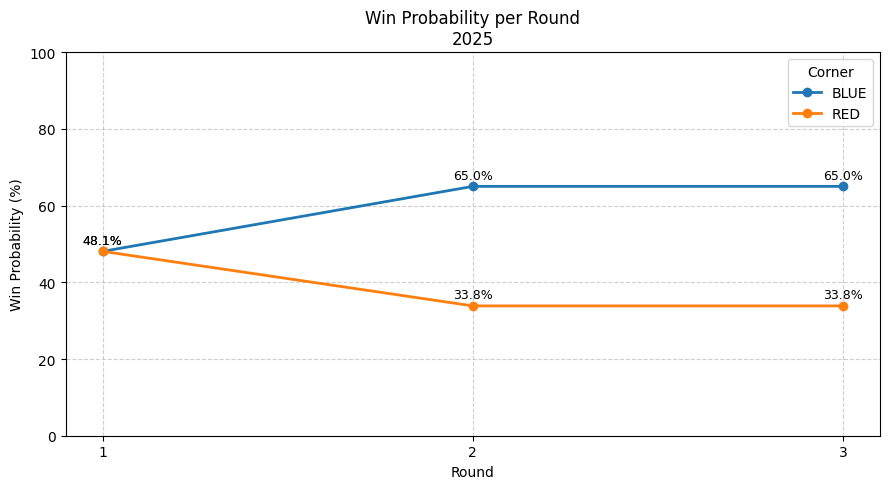

In [49]:
plot_batangas_match_1(df_infer)



In [52]:
from IPython.display import HTML, display
import sklearn

display(HTML(f"""
<h1 style='color:#1f3fb3;'>Logistic Regression Win Probability Prediction</h1>
<h3>Pencak Silat Match Outcome Analysis</h3>

<p style="font-size:14px; line-height:1.6;">
This section presents the evaluation and justification of the <b>Logistic Regression</b> model
used to predict <b>match win probability</b> in Pencak Silat competitions.
The model estimates the likelihood of a competitor winning based on cumulative
performance indicators observed during the match.
</p>

<hr>

<h2 style='color:#1f3fb3;'>A. Model Overview</h2>

<p style="font-size:14px; line-height:1.6;">
Logistic Regression is a <b>probabilistic binary classification algorithm</b> that models the
relationship between match performance features and the probability of winning.
Unlike rule-based classifiers, Logistic Regression directly estimates
<i>P(Win | Match Statistics)</i>, making it well-suited for decision-support systems.
</p>

<ul style="font-size:14px;">
<li>Produces <b>interpretable probability outputs</b></li>
<li>Stable on <b>small to medium-sized datasets</b></li>
<li>Low risk of overfitting compared to complex models</li>
<li>Efficient for real-time inference</li>
</ul>

<hr>

<h2 style='color:#1f3fb3;'>B. Test Set Evaluation</h2>

<table style="width:100%; border-collapse:collapse;" border="1" cellpadding="8">
<tr style="background:#1f3fb3; color:white;">
<th>Metric</th><th>Value</th><th>Interpretation</th>
</tr>
<tr>
<td><b>Accuracy</b></td>
<td><b>0.854</b></td>
<td>The model correctly predicts match outcomes in approximately 85% of cases.</td>
</tr>
<tr>
<td><b>ROC–AUC</b></td>
<td><b>0.865</b></td>
<td>Strong ability to distinguish between winning and losing outcomes.</td>
</tr>
</table>

<hr>

<h2 style='color:#1f3fb3;'>C. Classification Behavior Analysis</h2>

<table style="width:100%; border-collapse:collapse;" border="1" cellpadding="8">
<tr style="background:#1f3fb3; color:white;">
<th>Class</th><th>Precision</th><th>Recall</th><th>F1-Score</th><th>Support</th>
</tr>
<tr><td>Lose (0)</td><td>0.87</td><td>0.83</td><td>0.85</td><td>24</td></tr>
<tr><td>Win (1)</td><td>0.84</td><td>0.88</td><td>0.86</td><td>24</td></tr>
</table>

<p style="font-size:14px;">
<b>Interpretation:</b> Precision and recall are well balanced across win and loss classes,
indicating that the model does not favor one outcome over the other.
</p>

<hr>

<h2 style='color:#1f3fb3;'>D. Confusion Matrix Interpretation</h2>

<pre style="font-size:14px;">
[[20  4]
 [ 3 21]]
</pre>

<p style="font-size:14px;">
Out of 48 test cases, only 7 misclassifications were observed.
Errors are evenly distributed, suggesting a stable and unbiased decision boundary.
</p>

<hr>

<h2 style='color:#1f3fb3;'>E. Overfitting Check (Cross-Validation)</h2>

<table style="width:100%; border-collapse:collapse;" border="1" cellpadding="8">
<tr style="background:#1f3fb3; color:white;">
<th>Validation</th><th>Scores</th><th>Mean ROC–AUC</th><th>Conclusion</th>
</tr>
<tr>
<td>5-Fold Cross-Validation</td>
<td style="font-family:monospace;">
[0.807, 0.994, 0.980, 0.842, 0.816]
</td>
<td><b>0.888</b></td>
<td>Cross-validation performance closely matches test ROC–AUC, indicating no overfitting.</td>
</tr>
</table>

<hr>

<h2 style='color:#1f3fb3;'>F. Algorithm Comparison</h2>

<table style="width:100%; border-collapse:collapse;" border="1" cellpadding="8">
<tr style="background:#1f3fb3; color:white;">
<th>Model</th><th>Test Accuracy</th><th>Test ROC–AUC</th><th>CV ROC–AUC</th>
</tr>
<tr><td>Linear SVM</td><td>0.875</td><td>0.865</td><td>0.890</td></tr>
<tr><td><b>Logistic Regression</b></td><td><b>0.854</b></td><td><b>0.865</b></td><td><b>0.888</b></td></tr>
<tr><td>Decision Tree</td><td>0.875</td><td>0.872</td><td>0.850</td></tr>
</table>

<hr>

<h2 style='color:#1f3fb3;'>G. Why Logistic Regression Is a Good Fit</h2>

<ul style="font-size:14px; line-height:1.6;">
<li><b>Interpretability:</b> Outputs true win probabilities that can be directly explained to coaches.</li>
<li><b>Generalization:</b> Comparable cross-validation performance to Linear SVM with lower complexity.</li>
<li><b>Stability on Small Data:</b> Performs reliably with approximately 484 match-level observations.</li>
<li><b>Decision Support Friendly:</b> Probability outputs integrate naturally with coaching guidance.</li>
<li><b>Lower Overfitting Risk:</b> Unlike Decision Trees, Logistic Regression avoids rule memorization.</li>
</ul>

<p style="font-size:14px;">
<b>Final Decision:</b> Logistic Regression was selected as the primary win probability model
because it offers the best balance between predictive performance, interpretability,
and deployment readiness for a real-time sports analytics system.
</p>

<hr>

<h2 style='color:#1f3fb3;'>H. Summary</h2>

<p style="font-size:14px;">
The Logistic Regression model demonstrated strong predictive performance and stable
generalization across validation folds. Its probabilistic outputs and transparent
decision logic make it particularly suitable for integration into the CombatTech
system as a match outcome prediction module.
</p>


<p style="font-size:14px;">
<p style="font-size:14px;">
Logistic Regression win probability prediction model, evaluation was tailored for a binary classification task using a grouped train–test split to prevent match-level data leakage. On the test set, the model achieved an accuracy of approximately 85.4% and a ROC-AUC score of about 0.865, demonstrating strong capability in distinguishing between winning and losing outcomes. The confusion matrix and classification report showed balanced precision and recall for both win and loss classes, indicating no bias toward either outcome. To check generalization and overfitting, a 5-fold cross-validation using ROC-AUC was applied, resulting in a mean CV ROC-AUC of approximately 0.888, which is very close to the test ROC-AUC. This alignment confirms that Logistic Regression provides stable and reliable probability estimates, making it well-suited for real-time match outcome prediction and integration into a coaching decision-support system.
</p>
</p>
"""))
